In [127]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle
from collections import Counter

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [189]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [114]:
from odours import odours

In [86]:
import driver; reload(driver)
from driver import RunResults

In [155]:
import results; reload(results)

base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
trials = base.split("odours", "outclass", "max")


Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


In [171]:
model = trials.model("Free")
metric = "ratio"
df = model.report(metric, extra_fields=["outclass"]).sort_values(by=["outclass"])
df

,seed,λ,outclass,ratio
282,47,3.162278e+05,Acid,0.214258
154,25,1.000000e+07,Acid,0.309846
36,6,3.162278e+05,Acid,0.191302
236,39,1.000000e+06,Acid,0.323668
241,40,3.162278e+04,Acid,0.195724
...,...,...,...,...
95,15,3.162278e+06,Ketone,0.452601
88,14,3.162278e+06,Ketone,0.320834
263,43,1.000000e+07,Ketone,0.202339
77,12,3.162278e+07,Ketone,0.334768


In [177]:
# Get the distribution of how close the model correlations are to the output
extra_fields = {"outclass":"Ketone"}
vals = []
for seeds in range(50):
    for trains in range(10):
        res = model.extract(seed=seeds, train=trains, metric=metric, **extra_fields)
        corrs = res.vld_corrs
        in_out = np.mean((corrs["Cin"] - corrs["Cstar"])**2)**0.5
        est_out=np.mean((corrs["Cest"] - corrs["Cstar"])**2)**0.5
        vals.append(est_out/in_out)
        
        

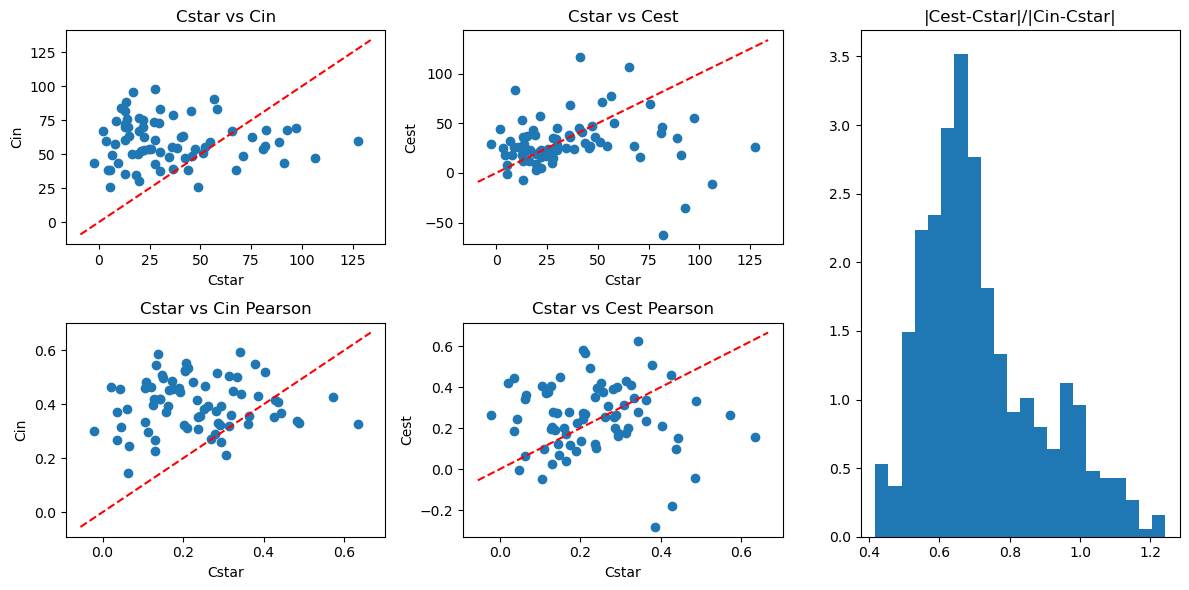

In [187]:
from matplotlib.gridspec import GridSpec
res = model.extract(seed=0, train=0, metric=metric, **extra_fields)
covs = res.vld
corrs = res.vld_corrs
 
is_square = covs.Cin.shape[0] == covs.Cin.shape[1]
fig = plt.figure(figsize=(12, 6))
if is_square:
    gs = GridSpec(2,4)
    # The first three columns of hte first row are Cin, Cstar, Cest
    # Those of the second row are the corresponding pearson correlations
    for i, ds in enumerate(["Cin", "Cstar", "Cest"]):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(getattr(covs, ds))
        ax.set_title(ds)
        ax = fig.add_subplot(gs[1, i])
        ax.imshow(corrs[ds], vmin=0, vmax=1, cmap="bwr")
        ax.set_title(f"{ds} Pearson")
else:
    # Plot as a scatter of Cstar vs Cin, Cstar vs Cest
    gs = GridSpec(2, 3)
    for i, ds in enumerate(["Cin", "Cest"]):
        ax = fig.add_subplot(gs[0, i])
        ax.scatter(covs.Cstar.flatten(),getattr(covs, ds).flatten())
        ax.set_title(f"Cstar vs {ds}")
        ax.set_xlabel("Cstar")
        ax.set_ylabel(ds)
        xl = ax.get_xlim()
        ax.plot(xl, xl, ls="--", color="r")
        ax = fig.add_subplot(gs[1, i])
        ax.scatter(corrs["Cstar"].flatten(), corrs[ds].flatten())
        ax.set_title(f"Cstar vs {ds} Pearson")
        ax.set_xlabel("Cstar")
        ax.set_ylabel(f"{ds}")
        xl = ax.get_xlim()
        ax.plot(xl, xl, ls="--", color="r")
 
    
ax = fig.add_subplot(gs[:, -1])
ax.hist(vals, bins=int(np.sqrt(len(vals))), density=True)
ax.set_title("|Cest-Cstar|/|Cin-Cstar|")
tight_layout()

## Figure for the Paper

In [273]:
reload(results)
selection_metric = "ratio"
splits = [
    ("trials", "random", "max"),
    ("odours", "random", "max"),
    ("odours", "inclass", "max"),
    ("odours", "outclass", "max")
] 
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
split = base.split(*splits[1])
model = split.model("Diag")
model.df["ref"].unique(), model.df["seed"].unique()

Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_random_max.p.


(array(['train[0]', 'train[1]', 'train[2]', 'train[3]', 'train[4]',
        'train[5]', 'train[6]', 'train[7]', 'train[8]', 'train[9]'],
       dtype=object),
 array([ 6, 44,  5, 43, 35, 13,  8,  1, 10, 23, 19, 12, 42,  3, 16,  4, 15,
        29, 47, 49,  9, 33, 45, 32, 30,  2,  0, 18, 25, 22, 46, 27, 37, 36,
        17, 48, 24, 34, 39, 41, 20, 40, 31, 26, 21, 28, 14, 38,  7, 11]))

In [305]:
def vld_fun_ratio(vld):
    in_out = np.mean((vld.Cin - vld.Cstar)**2)**0.5
    est_out=np.mean((vld.Cest - vld.Cstar)**2)**0.5
    return in_out, est_out 

def vld_fun_corr(corrs):
    in_out = np.mean((corrs["Cin"] - corrs["Cstar"])**2)**0.5
    est_out=np.mean((corrs["Cest"] - corrs["Cstar"])**2)**0.5
    return in_out, est_out

In [309]:
# Import cartesiaon product
from itertools import product
selection_metric = "ratio"
records = []
for split_name in splits:
    split = base.split(*split_name)
    for model_name in ["Diag", "Free"]:
        model   = split.model(model_name)
        n_train = len(model.df["ref"].unique())
        #report  = model.report(metric=selection_metric, extra_fields = ["outclass"] if "outclass" in split_name else [])     
        n_seeds = len(model.df["seed"].unique())
        # I wanted to use report to get the best parameter values, but extract already does that.
        # All in need to know is whether to include the outclass
        outclasses = model.df["outclass"].unique()
        iterable = product(range(n_seeds), range(n_train), outclasses)
        for seed, train, outclass in tqdm(iterable, total=n_seeds*n_train*len(outclasses)):
            extra_fields = {"outclass":outclass} if "outclass" in split_name else {}
            res = model.extract(seed=seed, train=train, metric=selection_metric, **extra_fields)
                        
            cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
            corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
            records.append({
                "sampler": split_name[0],
                "mode": split_name[1],
                "n_od_train": split_name[2],
                "model": model_name,
                "seed": seed,
                "train": train,
                "outclass": outclass,
                "cov_in_out": cov_in_out,
                "cov_est_out": cov_est_out,
                "corr_in_out": corr_in_out,
                "corr_est_out": corr_est_out
            })
df = pd.DataFrame(records)



Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/trials_random_max.p.


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 405.24it/s]


Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_random_max.p.


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:02<00:00, 184.30it/s]


Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_inclass_max.p.


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:02<00:00, 192.01it/s]


Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:26<00:00, 34.52it/s]


In [310]:
# Save the df to disk
with open(proj_path + "/model-fitting/generalization_results.pkl", "wb") as f:
    pickle.dump(df, f)

In [317]:
df.head()

,sampler,mode,n_od_train,model,seed,train,outclass,cov_in_out,cov_est_out,corr_in_out,corr_est_out
0,trials,random,max,Diag,0,0,None,55.804145,27.220790,0.304090,0.180649
1,trials,random,max,Diag,0,1,None,56.363654,28.348964,0.304578,0.182164
2,trials,random,max,Diag,0,2,None,56.652427,28.415148,0.306596,0.183216
3,trials,random,max,Diag,0,3,None,56.038860,27.723095,0.305300,0.181387
4,trials,random,max,Diag,0,4,None,55.703192,27.519757,0.305495,0.182769


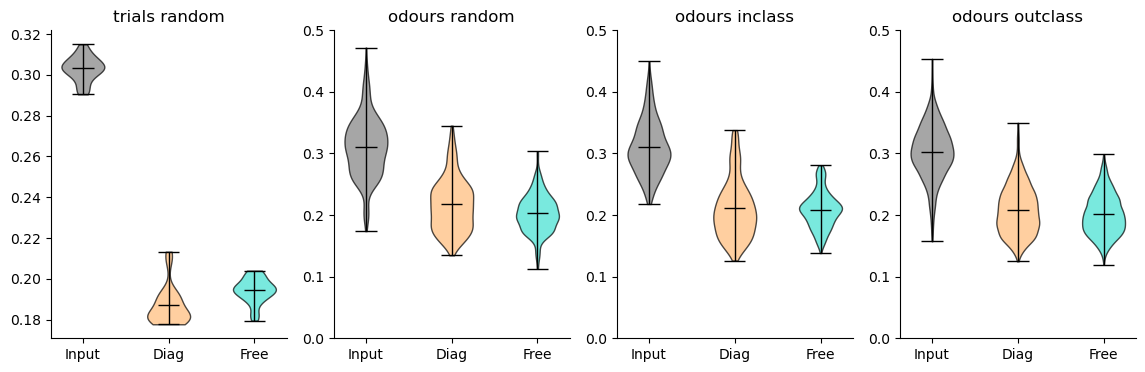

In [387]:
import proc_fit_models as pfm; reload(pfm)
prefix = "corr"
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(14, 4))
split_descr = {"trials": ("trials", "random"),
               "odours_random,": ("odours", "random"),
               "odours_inclass": ("odours", "inclass"),
               "odours_outclass": ("odours", "outclass")}
order = ["trials", "odours_random,", "odours_inclass", "odours_outclass"]
cols = ["Gray", pfm.model_color("Diag"), pfm.model_color("Free")]
for i, (axi, split_name) in enumerate(zip(ax.flatten(), order)):
    sampler, mode = split_descr[split_name]
    split_mask = (df["sampler"] == sampler) & (df["mode"] == mode) 
    in_out = df[split_mask & (df['model']=="Diag")][f"{prefix}_in_out"].values
    diag_est_out = df[split_mask & (df['model']=="Diag")][f"{prefix}_est_out"].values
    free_est_out = df[split_mask & (df['model']=="Free")][f"{prefix}_est_out"].values
    # Create a violin plot of the three distributions
    parts = axi.violinplot([in_out, diag_est_out, free_est_out], showmeans=True)
    for pc, col in zip(parts['bodies'], cols):
        pc.set_facecolor(col)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
    for partname in ('cbars','cmins','cmaxes', 'cmeans'):
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1)
    axi.set_xticks([1, 2, 3])
    axi.set_xticklabels(["Input", "Diag", "Free"])
    axi.set_title(f"{sampler} {mode}")
    i >0 and axi.set_ylim(0, 0.5)
    [ax[i].spines[spine].set_visible(False) for spine in ['top', 'right']]

Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/trials_random_max.p.
Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_random_max.p.


/tmp/ipykernel_3908296/1216279889.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x.flatten(), y.flatten(), c=c)


Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_inclass_max.p.


/tmp/ipykernel_3908296/1216279889.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x.flatten(), y.flatten(), c=c)


Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


/tmp/ipykernel_3908296/1216279889.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x.flatten(), y.flatten(), c=c)


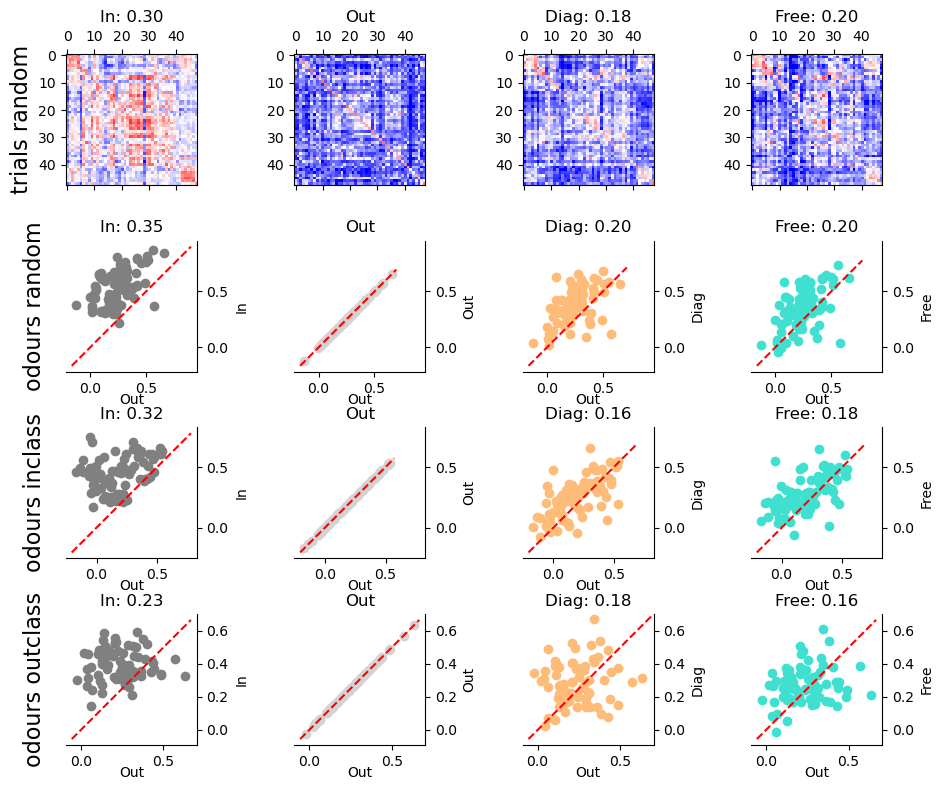

In [384]:
# For each of the conditions, plot an actual data point (Cin, Cstar, Cest_diag, Cest_free) for a single seed and train. 
# This will check whether the violin plots are representative of the actual data points.
# We'll have one row per condition, and four columns for Cin, Cstar, Cest_diag, Cest_free. 
def scatter_plot(ax, x, y, xlabel, ylabel, c):
    ax.scatter(x.flatten(), y.flatten(), c=c)
    ax.set_xlabel(xlabel, labelpad=-2)
    ax.set_ylabel(ylabel)
    xl = ax.get_xlim()
    yl = ax.get_ylim()
    ll = np.min((xl[0], yl[0]))
    ul = np.max((xl[1], yl[1]))
    lims = [ll, ul]
    ax.plot(lims, lims, ls="--", color="r")
    # 1. Die Markierungen (Zahlenwerte/Ticks) auf die rechte Seite verschieben
    ax.yaxis.tick_right()
    # 2. Die Position des Labels (Text) auf die rechte Seite setzen
    ax.yaxis.set_label_position("right")

fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(10, 8))
vmin = {"cov": None, "corr": 0}
vmax = {"cov": None, "corr": 1}
cmap = {"cov": "viridis", "corr": "bwr"}
ttls = ["In", "Out", "Diag", "Free"]
append_to_title = lambda ax, s: ax.set_title(ax.get_title() + s)
prepend_to_title = lambda ax, s: ax.set_title(s + ax.get_title())
for i, split_name in enumerate(order):
    descr = split_descr[split_name]
    split = base.split(sampler=descr[0], mode=descr[1], n_od_train="max")
    extra_fields = {"outclass":"Ketone"} if "outclass" in split_name else {}
    for name in ["Diag", "Free"]:
        model = split.model(name)
        res = model.extract(seed=0, train=0, metric=selection_metric, **extra_fields)
        covs = {k: getattr(res.vld, k) for k in ["Cin", "Cstar", "Cest"]}
        corrs = res.vld_corrs
        cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
        corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
 
        vals = covs if prefix == "cov" else corrs
        matshow_kwargs = {"vmin": vmin[prefix], "vmax": vmax[prefix], "cmap": cmap[prefix]} 
        plot_fun = lambda ax, k, ylab, c: ax.matshow(vals[k], **matshow_kwargs) if i == 0 else scatter_plot(ax, vals["Cstar"], vals[k], "Out", ylab, c)

        in_val = cov_in_out if prefix == "cov" else corr_in_out
        est_val = cov_est_out if prefix == "cov" else corr_est_out
 
        if name == "Diag":
            plot_fun(ax[i,0], "Cin", "In", "Gray")
            append_to_title(ax[i,0], f": {in_val:.2f}")
            plot_fun(ax[i,1], "Cstar", "Out", "LightGray")
            plot_fun(ax[i,2], "Cest", "Diag", pfm.model_color("Diag"))
            append_to_title(ax[i,2], f": {est_val:.2f}")
        else:
            plot_fun(ax[i,3], "Cest", "Free", pfm.model_color("Free"))
            append_to_title(ax[i,3], f": {est_val:.2f}")
    if i >= 0:
        [prepend_to_title(axi, ttl) for axi, ttl in zip(ax[i,:], ttls)]

    if i > 0:
        # Share the x and y lims with the first plot in the row
        for j in range(4):
            ax[i,j].set_xlim(ax[i,0].get_xlim())
            ax[i,j].set_ylim(ax[i,0].get_ylim())
            ax[i,j].set_aspect('equal')
            # Turn top and right spines off
            [ax[i,j].spines[spine].set_visible(False) for spine in ['top', 'left']]

    # Put the split description on the left of the row
    ax[i,0].text(-0.25 + 0.1*(i>0), 0.5, f"{descr[0]} {descr[1]}", va='center', ha='right', 
                 fontsize=16, transform=ax[i,0].transAxes, rotation=90)
tight_layout(w_pad=0, h_pad=0)

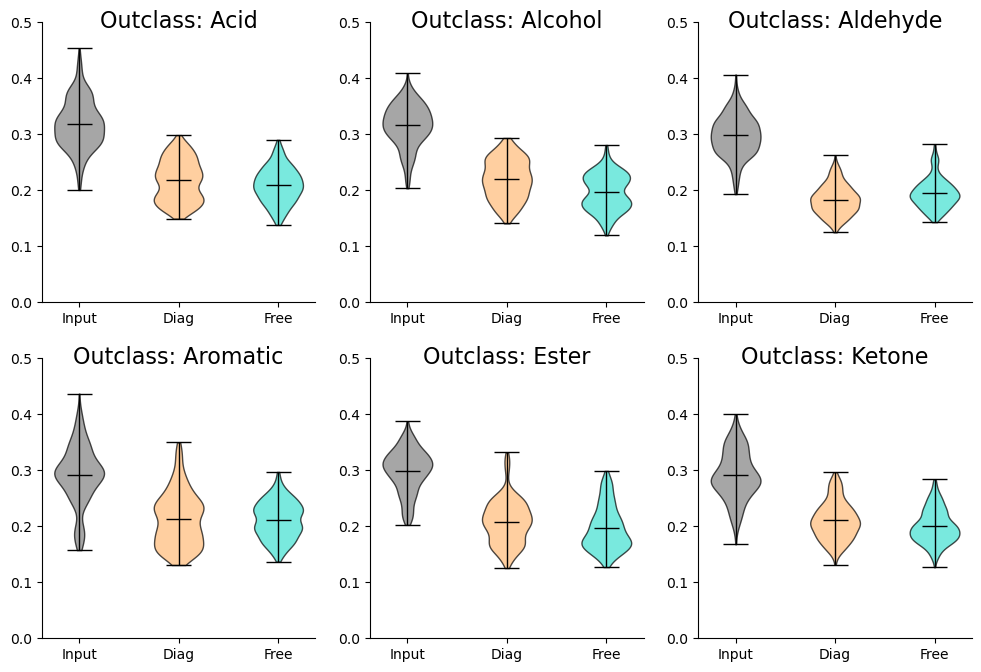

In [392]:
# Now just look at outclass, by outclass
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
outclasses = sorted(df[df.outclass.notnull()]["outclass"].unique())
for i, (axi, outclass) in enumerate(zip(ax.flatten(), outclasses)):
    split_mask = (df["sampler"] == "odours") & (df["mode"] == "outclass") & (df["outclass"] == outclass)
    in_out = df[split_mask & (df['model']=="Diag")][f"{prefix}_in_out"].values
    diag_est_out = df[split_mask & (df['model']=="Diag")][f"{prefix}_est_out"].values
    free_est_out = df[split_mask & (df['model']=="Free")][f"{prefix}_est_out"].values
    # Create a violin plot of the three distributions
    parts = axi.violinplot([in_out, diag_est_out, free_est_out], showmeans=True)
    for pc, col in zip(parts['bodies'], cols):
        pc.set_facecolor(col)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
    for partname in ('cbars','cmins','cmaxes', 'cmeans'):
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1)
    axi.set_xticks([1, 2, 3])
    axi.set_xticklabels(["Input", "Diag", "Free"])
    axi.set_title(f"Outclass: {outclass}", fontsize=16, y=0.95)
    axi.set_ylim(0, 0.5)
    [axi.spines[spine].set_visible(False) for spine in ['top', 'right']]

In [403]:
class_counts = Counter(odours.classes)
class_counts["Ester"]

15

Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


/tmp/ipykernel_3908296/1216279889.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x.flatten(), y.flatten(), c=c)
/tmp/ipykernel_3908296/1216279889.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x.flatten(), y.flatten(), c=c)
/tmp/ipykernel_3908296/1216279889.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have prece

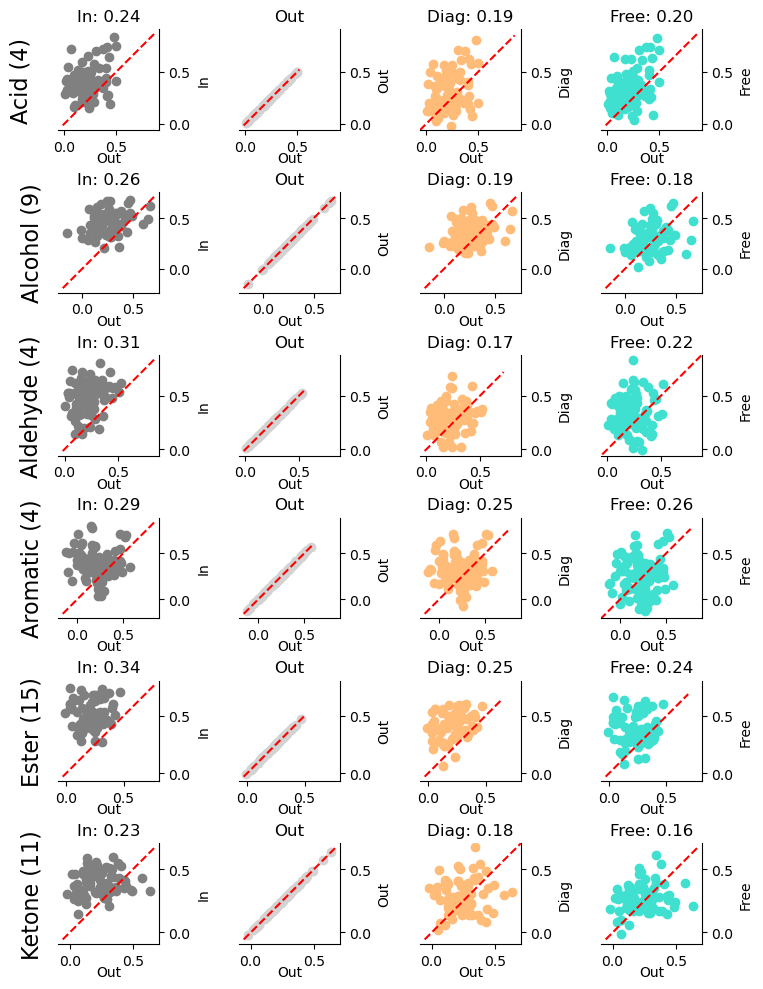

In [404]:
reload(results)
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(8, 10))
for i, outclass in enumerate(outclasses): 
    split = base.split(sampler="odours", mode="outclass", n_od_train="max")
    extra_fields = {"outclass": outclass}
    for name in ["Diag", "Free"]:
        model = split.model(name)
        res = model.extract(seed=0, train=0, metric=selection_metric, **extra_fields)
        covs = {k: getattr(res.vld, k) for k in ["Cin", "Cstar", "Cest"]}
        corrs = res.vld_corrs
        cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
        corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
 
        vals = covs if prefix == "cov" else corrs
        plot_fun = lambda ax, k, ylab, c: scatter_plot(ax, vals["Cstar"], vals[k], "Out", ylab, c)

        in_val = cov_in_out if prefix == "cov" else corr_in_out
        est_val = cov_est_out if prefix == "cov" else corr_est_out
 
        if name == "Diag":
            plot_fun(ax[i,0], "Cin", "In", "Gray")
            append_to_title(ax[i,0], f": {in_val:.2f}")
            plot_fun(ax[i,1], "Cstar", "Out", "LightGray")
            plot_fun(ax[i,2], "Cest", "Diag", pfm.model_color("Diag"))
            append_to_title(ax[i,2], f": {est_val:.2f}")
        else:
            plot_fun(ax[i,3], "Cest", "Free", pfm.model_color("Free"))
            append_to_title(ax[i,3], f": {est_val:.2f}")
    
    [prepend_to_title(axi, ttl) for axi, ttl in zip(ax[i,:], ttls)]

    # Share the x and y lims with the first plot in the row
    for j in range(4):
        ax[i,j].set_xlim(ax[i,0].get_xlim())
        ax[i,j].set_ylim(ax[i,0].get_ylim())
        ax[i,j].set_aspect('equal')
        # Turn top and right spines off
        [ax[i,j].spines[spine].set_visible(False) for spine in ['top', 'left']]

    # Put the split description on the left of the row
    ax[i,0].text(-0.25 + 0.1*(i>0), 0.5, f"{outclass} ({class_counts[outclass]})", va='center', ha='right', 
                 fontsize=16, transform=ax[i,0].transAxes, rotation=90)
tight_layout(w_pad=0, h_pad=0.5)